### Tasks

* 1. Build a simple autoencoder in Python using Keras to compress and reconstruct 28x28 grayscale images from the Fashion MNIST dataset. Train for 5 epochs and display one original and its reconstructed image side by side.

In [71]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import fashion_mnist

In [72]:
(x_train, _), (x_test, _) = fashion_mnist.load_data()

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

In [73]:
input_shape = (28, 28, 1)

encoder_input = layers.Input(shape=(28, 28, 1))
x = layers.Flatten()(encoder_input)
encoded = layers.Dense(64, activation='relu')(x) 
x = layers.Dense(784, activation='sigmoid')(encoded)
decoded = layers.Reshape((28, 28, 1))(x)

In [74]:
autoencoder_mse = models.Model(encoder_input, decoded)
autoencoder_mse.compile(optimizer='adam', loss='mse')

In [75]:
autoencoder_mse.fit(
    x_train, x_train,
    epochs=5,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test)
)

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0535 - val_loss: 0.0292
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0241 - val_loss: 0.0205
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0179 - val_loss: 0.0160
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0147 - val_loss: 0.0138
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0131 - val_loss: 0.0126


In [76]:
reconstructed_mse = autoencoder_mse.predict(x_test[:1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step


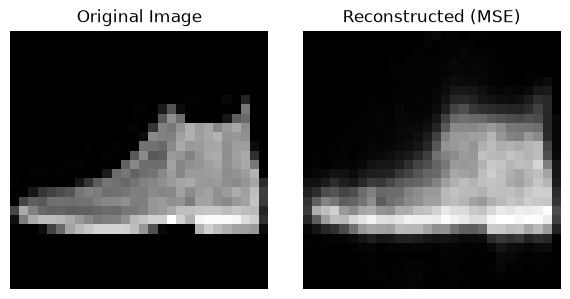

In [77]:


plt.figure(figsize=(6, 3))

# Original
plt.subplot(1, 2, 1)
plt.imshow(x_test[0].squeeze(), cmap='gray')
plt.title("Original Image")
plt.axis('off')

# Reconstructed
plt.subplot(1, 2, 2)
plt.imshow(reconstructed_mse[0].squeeze(), cmap='gray')
plt.title("Reconstructed (MSE)")
plt.axis('off')

plt.tight_layout()
plt.show()

* 2. Modify your autoencoder's loss function to use Binary Crossentropy (BCE) instead of Mean Squared Error (MSE), then compare the reconstruction quality visually for 3 test images.<br><br><em><strong>Hint:</strong> Use model.compile(loss='binary_crossentropy', optimizer='adam').</em>

In [78]:
autoencoder_bce = models.Model(encoder_input, decoded)
autoencoder_bce.compile(optimizer='adam', loss='binary_crossentropy')

In [79]:
autoencoder_bce.fit(
    x_train, x_train,
    epochs=5,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test)
)

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.2844 - val_loss: 0.2838
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2802 - val_loss: 0.2812
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2782 - val_loss: 0.2796
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2768 - val_loss: 0.2785
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2757 - val_loss: 0.2775


In [80]:
test_samples = x_test[:3]
reconstructed_mse_3 = autoencoder_mse.predict(test_samples)
reconstructed_bce_3 = autoencoder_bce.predict(test_samples)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


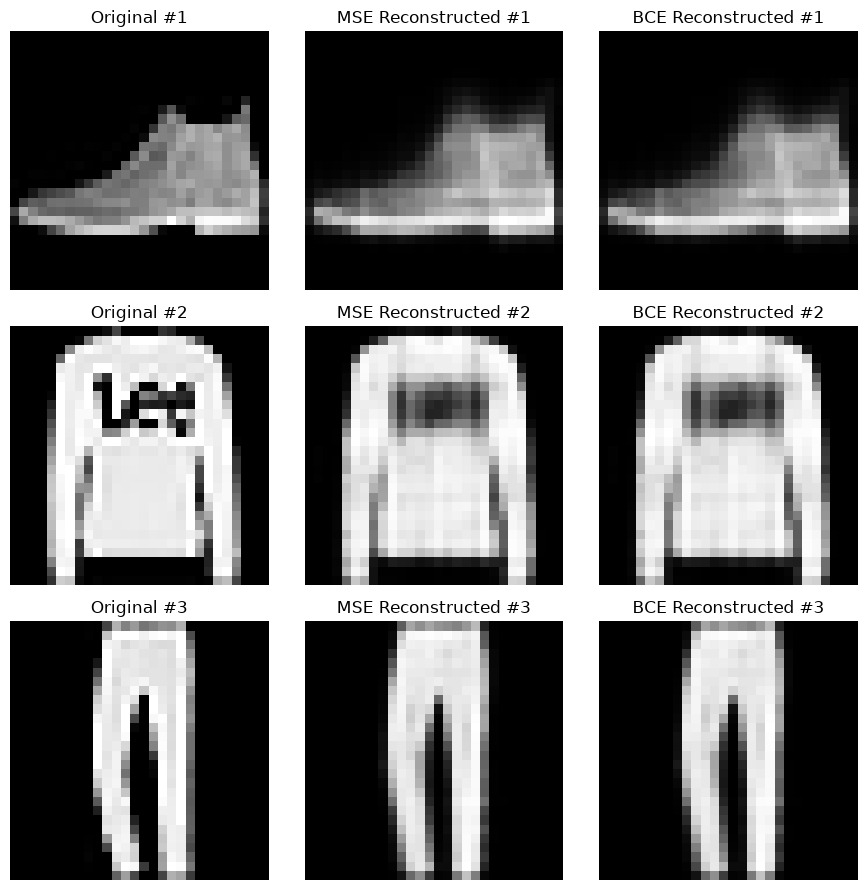

In [81]:
plt.figure(figsize=(9, 9))
for i in range(3):
    # Original
    plt.subplot(3, 3, i*3 + 1)
    plt.imshow(test_samples[i].squeeze(), cmap='gray')
    plt.title(f"Original #{i+1}")
    plt.axis('off')
    
    # MSE Reconstruction
    plt.subplot(3, 3, i*3 + 2)
    plt.imshow(reconstructed_mse_3[i].squeeze(), cmap='gray')
    plt.title(f"MSE Reconstructed #{i+1}")
    plt.axis('off')
    
    # BCE Reconstruction
    plt.subplot(3, 3, i*3 + 3)
    plt.imshow(reconstructed_bce_3[i].squeeze(), cmap='gray')
    plt.title(f"BCE Reconstructed #{i+1}")
    plt.axis('off')

plt.tight_layout()
plt.show()

* 3. Use your trained autoencoder to denoise images: add random noise to 10 Fashion MNIST test images, pass them through the autoencoder, and display the noisy and denoised outputs together.

In [82]:
noise_factor = 0.25
x_test_noisy = x_test[:10] + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test[:10].shape)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

In [83]:
denoised_images = autoencoder_bce.predict(x_test_noisy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


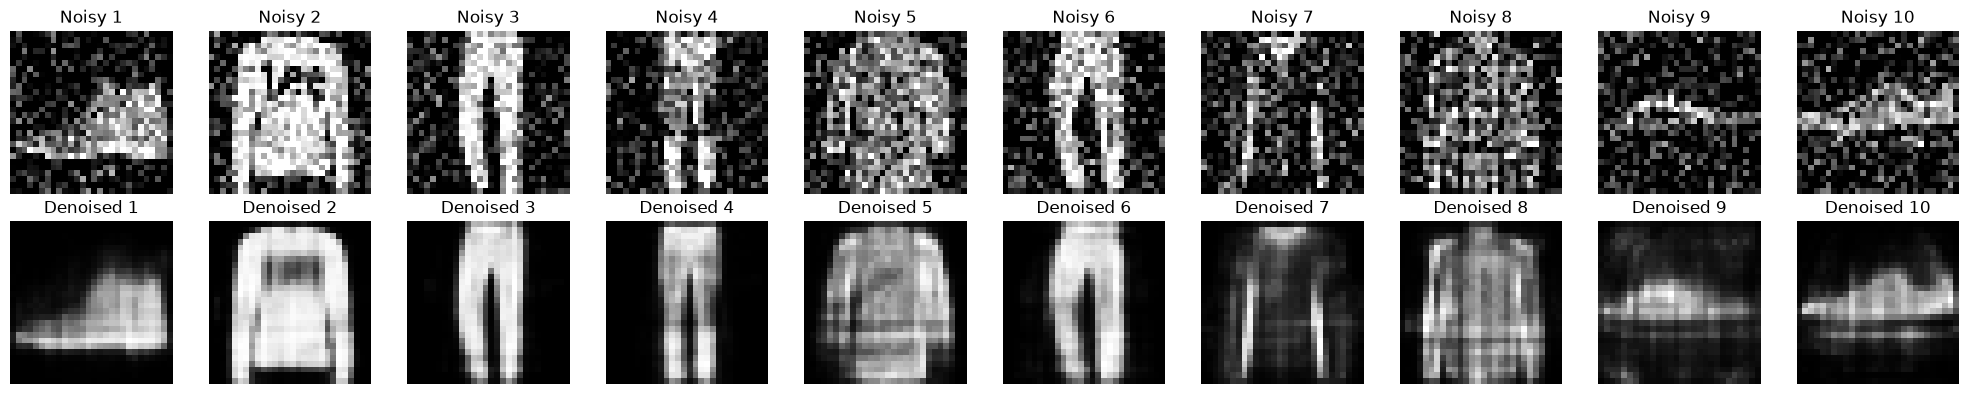

In [84]:
plt.figure(figsize=(20, 4))
for i in range(10):
    # Noisy Image
    ax = plt.subplot(2, 10, i + 1)
    plt.imshow(x_test_noisy[i].squeeze(), cmap='gray')
    plt.title(f"Noisy {i+1}")
    plt.axis('off')

    # Denoised Output
    ax = plt.subplot(2, 10, i + 11)
    plt.imshow(denoised_images[i].squeeze(), cmap='gray')
    plt.title(f"Denoised {i+1}")
    plt.axis('off')

plt.tight_layout()
plt.show()

* 4. Build a Variational Autoencoder (VAE) using Keras for the Fashion MNIST dataset. After training, sample 5 random points from the latent space and generate new images from these points.<br><br><em><strong>Hint:</strong> Use the VAE's decoder to generate images from sampled latent vectors.</em>

In [85]:
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

latent_dim = 2

In [86]:
encoder_inputs = layers.Input(shape=(28, 28, 1))
x = layers.Flatten()(encoder_inputs)
x = layers.Dense(128, activation="relu")(x)
z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
z = Sampling()([z_mean, z_log_var])

encoder = models.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")

In [87]:
latent_inputs = layers.Input(shape=(latent_dim,))
x = layers.Dense(128, activation="relu")(latent_inputs)
x = layers.Dense(784, activation="sigmoid")(x)
decoder_outputs = layers.Reshape((28, 28, 1))(x)

decoder = models.Model(latent_inputs, decoder_outputs, name="decoder")

In [88]:
class VAE(models.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = tf.keras.metrics.Mean(name="total_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            
            # Reconstruction Loss
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    tf.keras.losses.binary_crossentropy(data, reconstruction), axis=(1, 2)
                )
            )
            
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
            )
            
            total_loss = reconstruction_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        return {"loss": self.total_loss_tracker.result()}

In [89]:
vae = VAE(encoder, decoder)
vae.compile(optimizer=tf.keras.optimizers.Adam())

In [90]:
vae.fit(x_train, epochs=5, batch_size=128)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 324.4583
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 283.9663
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 276.9356
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 273.9424
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 271.6801


In [92]:
# Sample 5 random points from Standard Normal Latent Space N(0, I)
np.random.seed(42)
random_latent_points = np.random.normal(size=(5, latent_dim))

# Generate images using the trained decoder
generated_images = vae.decoder.predict(random_latent_points)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


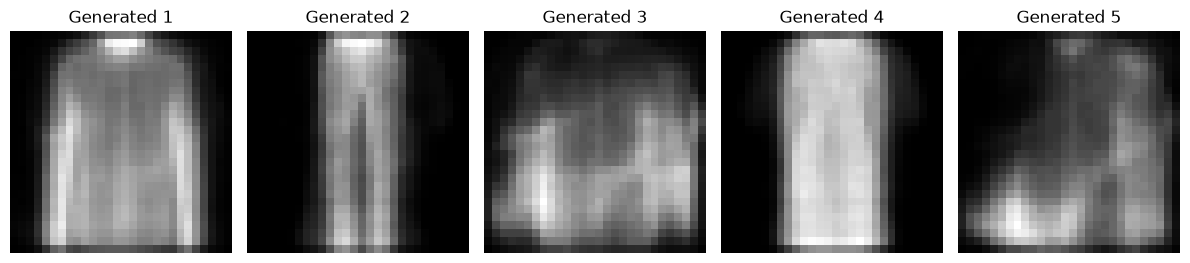

In [94]:
plt.figure(figsize=(12, 3))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(generated_images[i].squeeze(), cmap='gray')
    plt.title(f"Generated {i+1}")
    plt.axis('off')

plt.tight_layout()
plt.show()

* 5. Use ChatGPT to explain in your own words what KL-divergence loss does in a VAE and why it is needed. Paste your prompt and ChatGPT's response as your answer.

----

**My Prompt:**

Explain Kullback-Leibler (KL) divergence loss in Variational Autoencoders (VAEs) in simple, intuitive terms. Why is it necessary alongside reconstruction loss, and what happens to the latent space if we remove it?

**ChatGPT's Response:**

Kullback-Leibler (KL) Divergence loss in a Variational Autoencoder (VAE) acts as a regularizer for the latent space.

### 1. What KL-Divergence Does:
Reconstruction loss forces the VAE to accurately encode and rebuild training images. However, without constraints, the encoder would scatter encoded data points into isolated clusters across an infinite latent space. 

KL-Divergence measures how much the latent space probability distribution (produced by the encoder) deviates from a standard Normal distribution—a Gaussian distribution centered at mean 0 with variance 1: N(0, I). 

By minimizing KL divergence, the model forces the encoder to structure latent representations continuously and tightly around zero.

### 2. Why It Is Needed:
1. Continuity: Ensures close latent points generate smooth, similar images rather than completely different outputs.
2. Completeness: Prevents "dead zones" or empty gaps in latent space. This allows you to pick any random coordinate from N(0, I) during inference and decode a realistic, brand-new synthetic image.

### Summary:
- Reconstruction Loss = Makes images look sharp and accurate.
- KL-Divergence Loss = Makes the latent space smooth, continuous, and sampleable.
Together, they ensure the network acts as a generative model rather than a basic compression tool.